In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('hotel_bookings.csv')

# First look at the data
print(df.shape)        # How many rows and columns?
print(df.head())       # First 5 rows
print(df.info())       # Data types of each column
print(df.describe())   # Quick statistics

(119390, 32)
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Depo

In [3]:
# ============================================
# STEP 1: Check missing values
# ============================================
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])


          Missing Count  Missing %
company          112593  94.306893
agent             16340  13.686238
country             488   0.408744
children              4   0.003350


# ============================================
#            Data Cleaning      
# ============================================

In [4]:
# ============================================
# STEP 2: Fix missing values
# ============================================

# children → fill with 0 (most likely no children)
df['children'] = df['children'].fillna(0)

# country → fill with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# agent → fill with 0 (means no agent was used)
df['agent'] = df['agent'].fillna(0)

# company → drop column (93% missing, not useful)
df.drop(columns=['company'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())  # Should be 0

Missing values after cleaning:
0


In [5]:
# ============================================
# STEP 3: Fix outliers
# ============================================

# Remove rows where adr is negative or extremely high
df = df[df['adr'] >= 0]
df = df[df['adr'] <= 5000]

# Remove rows where adults = 0 (can't book with no adults)
df = df[df['adults'] > 0]

print(f"Dataset shape after cleaning: {df.shape}")

Dataset shape after cleaning: (118985, 31)


In [6]:
# ============================================
# STEP 4: Fix data types
# ============================================

# Convert reservation_status_date to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Convert arrival_date_month to category
df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=['January','February','March','April','May','June',
                'July','August','September','October','November','December'],
    ordered=True
)

print(df.dtypes)

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                      category
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

In [7]:
# ============================================
# STEP 5: Remove duplicates
# ============================================

before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"Removed {before - after} duplicate rows")
print(f"Final dataset shape: {df.shape}")

Removed 31983 duplicate rows
Final dataset shape: (87002, 31)


# ============================================
#            EDA & Visualization 
# ============================================

In [14]:
# Global plot settings
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 12

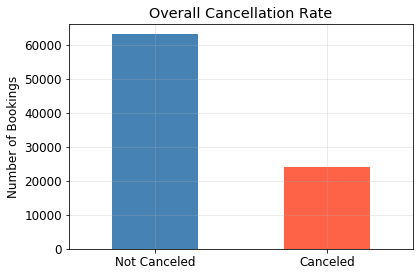

In [20]:
#Cancellation rate (Bar Chart):
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Overall cancellation rate
ffig, ax = plt.subplots(figsize=(6, 4))
df['is_canceled'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)
ax.set_title('Overall Cancellation Rate')
ax.set_ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

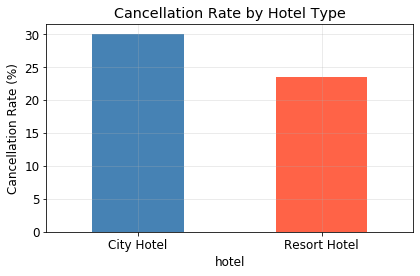

In [15]:
#Hotel type vs Cancellation (Grouped Bar):
# Plot 2: Cancellation by hotel type
fig, ax = plt.subplots(figsize=(6, 4))
df.groupby('hotel')['is_canceled'].mean().mul(100).plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_title('Cancellation Rate by Hotel Type')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

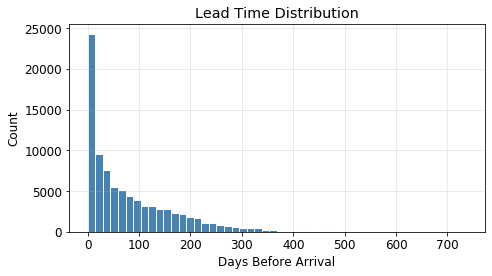

count    87002.000000
mean        79.867417
std         86.008625
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64


In [16]:
#Lead time distribution (Histogram):
# Plot 3: Lead time distribution
fig, ax = plt.subplots(figsize=(7, 4))
df['lead_time'].hist(bins=50, color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Lead Time Distribution')
ax.set_xlabel('Days Before Arrival')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(df['lead_time'].describe())

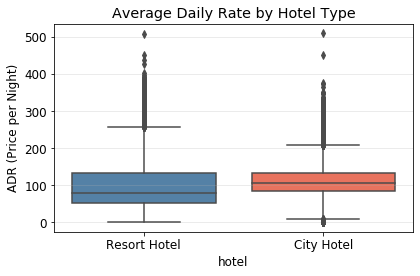

In [17]:
#ADR by hotel type (Boxplot):
# Plot 4: Average Daily Rate by hotel type
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='hotel', y='adr', palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Average Daily Rate by Hotel Type')
ax.set_ylabel('ADR (Price per Night)')
plt.tight_layout()
plt.show()

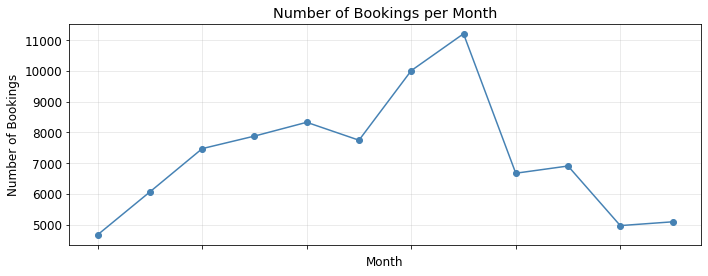

In [18]:
#Bookings per month (Line Chart):
# Plot 5: Monthly bookings trend
monthly = df.groupby('arrival_date_month', observed=True).size()
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(kind='line', marker='o', color='steelblue', ax=ax)
ax.set_title('Number of Bookings per Month')
ax.set_ylabel('Number of Bookings')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

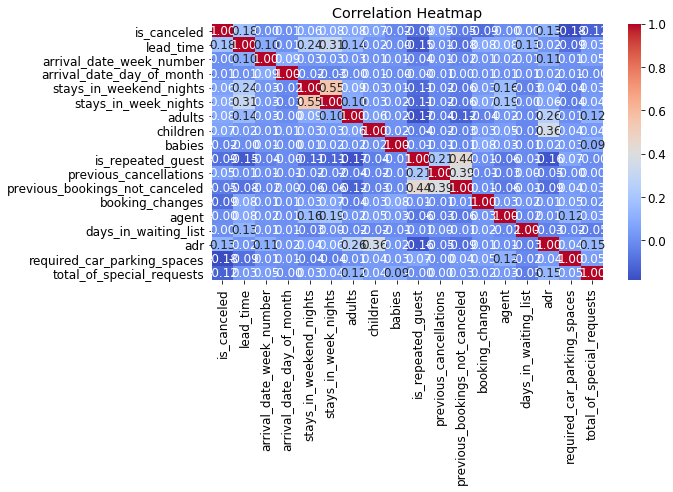

In [19]:
#Correlation Heatmap:
# Plot 6: Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))
numeric_cols = df.select_dtypes(include='number').drop(columns=['arrival_date_year'])
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

EDA Insights 📊
* Cancellation by Hotel Type → City Hotel has a higher cancellation rate (30%) compared to Resort Hotel (24%)
* Lead Time → Most bookings are made within the first 50 days before arrival. The longer the lead time, the higher the chance of cancellation
* Monthly Bookings → August is the busiest month for bookings, while January is the slowest
* ADR Boxplot → City Hotel has higher and more spread out prices compared to Resort Hotel
* Heatmap → lead_time and previous_cancellations have the strongest correlation with is_canceled

In [21]:
# ============================================
# FEATURE ENGINEERING
# ============================================

# Total nights stayed (weekend + weekdays)
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Total guests (adults + children + babies)
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Did the customer get the room they reserved?
df['room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

# Has the customer cancelled before?
df['is_returning_guest'] = (df['previous_bookings_not_canceled'] > 0).astype(int)

# Revenue per booking
df['total_revenue'] = df['adr'] * df['total_nights']

print("New features added successfully!")
print(df[['total_nights', 'total_guests', 'room_changed', 
          'is_returning_guest', 'total_revenue']].head())

New features added successfully!
   total_nights  total_guests  room_changed  is_returning_guest  total_revenue
0             0           2.0             0                   0            0.0
1             0           2.0             0                   0            0.0
2             1           1.0             1                   0           75.0
3             1           1.0             0                   0           75.0
4             2           2.0             0                   0          196.0


In [22]:
# Drop columns that are not useful for prediction
cols_to_drop = [
    'reservation_status',       # directly leaks the target
    'reservation_status_date',  # directly leaks the target
    'arrival_date_week_number', # redundant with month
    'arrival_date_day_of_month',# low importance
    'assigned_room_type',       # already used in room_changed
    'reserved_room_type',       # already used in room_changed
    'babies',                   # already used in total_guests
    'adults',                   # already used in total_guests
    'children',                 # already used in total_guests
    'stays_in_weekend_nights',  # already used in total_nights
    'stays_in_week_nights',     # already used in total_nights
]

df.drop(columns=cols_to_drop, inplace=True)

print(f"Remaining columns: {df.shape[1]}")
print(df.columns.tolist())

Remaining columns: 25
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'room_changed', 'is_returning_guest', 'total_revenue']


In [23]:
# Convert categorical text columns to numbers
categorical_cols = ['hotel', 'meal', 'country', 'market_segment',
                    'distribution_channel', 'deposit_type', 
                    'customer_type', 'arrival_date_month']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(df_encoded.head())

Shape after encoding: (87002, 226)
   is_canceled  lead_time  arrival_date_year  is_repeated_guest  \
0            0        342               2015                  0   
1            0        737               2015                  0   
2            0          7               2015                  0   
3            0         13               2015                  0   
4            0         14               2015                  0   

   previous_cancellations  previous_bookings_not_canceled  booking_changes  \
0                       0                               0                3   
1                       0                               0                4   
2                       0                               0                0   
3                       0                               0                0   
4                       0                               0                0   

   agent  days_in_waiting_list   adr  ...  arrival_date_month_March  \
0    0.0              

In [24]:
from sklearn.model_selection import train_test_split

# Target variable
X = df_encoded.drop(columns=['is_canceled'])
y = df_encoded['is_canceled']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train cancellation rate: {y_train.mean():.2%}")
print(f"y_test  cancellation rate: {y_test.mean():.2%}")

X_train: (69601, 225)
X_test:  (17401, 225)
y_train cancellation rate: 27.59%
y_test  cancellation rate: 27.13%


Summary of what we did :-
StepResultNew features created✅ 5 new columns
Useless columns dropped✅ 25 columns remaining
Encoding done✅ 226 columns after encoding
Train/Test split✅ 69,601 train — 17,401 test
Cancellation rate balanced✅ 27% in both train and test

# ============================================
# Modeling — we need at least 3 algorithms! 🤖
# ============================================

In [25]:
#Train 3 models:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# ============================================
# MODEL 1: Logistic Regression
# ============================================
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# ============================================
# MODEL 2: Decision Tree
# ============================================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# ============================================
# MODEL 3: Random Forest
# ============================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [26]:
#Compare models:
# ============================================
# COMPARE ALL MODELS
# ============================================
def evaluate_model(name, y_test, y_pred):
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Decision Tree",       y_test, dt_pred)
evaluate_model("Random Forest",       y_test, rf_pred)


--- Logistic Regression ---
Accuracy:  0.7928
Precision: 0.6783
Recall:    0.4497
F1 Score:  0.5408

--- Decision Tree ---
Accuracy:  0.8067
Precision: 0.6437
Recall:    0.6437
F1 Score:  0.6437

--- Random Forest ---
Accuracy:  0.8544
Precision: 0.7705
Recall:    0.6598
F1 Score:  0.7109


In [30]:
#Tune the best model (Random Forest):
from sklearn.model_selection import GridSearchCV

# ============================================
# HYPERPARAMETER TUNING - Random Forest
# ============================================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best F1 Score:   {grid_search.best_score_:.4f}")


Fitting 3 folds for each of 12 candidates, totalling 36 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:  2.6min finished



Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score:   0.7014


In [31]:
#Evaluate best model:
#============================================
# FINAL EVALUATION - Best Model
# ============================================
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)

evaluate_model("Random Forest (Tuned)", y_test, best_pred)


--- Random Forest (Tuned) ---
Accuracy:  0.8545
Precision: 0.7690
Recall:    0.6630
F1 Score:  0.7121


## Model Comparison Results

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Logistic Regression | 79.28% | 67.83% | 44.97% | 54.08% |
| Decision Tree | 80.67% | 64.37% | 64.37% | 64.37% |
| Random Forest | 85.44% | 77.05% | 65.98% | 71.09% |
| **Random Forest (Tuned)** | **85.45%** | **76.90%** | **66.30%** | **71.21%** |

## Key Insights

- **Random Forest is the best model** — highest accuracy and F1 score
- **Tuning improved the Recall slightly** — from 65.98% to 66.30%, 
which means it catches more cancellations
- **All metrics are well above 0.3** ✅ — which is the minimum required by the project